**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: Samuel Enrique Garza Montemayor
*   MATRÍCULA: A00829926

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [157]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pandas.api.types import CategoricalDtype

In [158]:

def graficar_variable_clasificada(
    df, col, clasif_asimetria="Simétrica", clasif_curtosis="Mesocúrtica"
):
    # 1. Calcular estadísticas
    media = df[col].mean()
    mediana = df[col].median()
    skewness = df[col].skew()
    kurtosis = df[col].kurt()

    plt.figure(figsize=(8, 5))

    # 2. Histograma CON la curva KDE activada (kde=True)
    sns.histplot(df[col], kde=True, color="skyblue", bins=25)

    # 3. Líneas punteadas para Media (Roja) y Mediana (Verde)
    plt.axvline(
        media,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Media: {media:.2f}",
    )
    plt.axvline(
        mediana,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}",
    )

    # 4. Título con Nombre de Variable y Clasificación
    plt.title(
        f"Variable: {col}\nClasificación: {clasif_asimetria} | {clasif_curtosis}",
        fontsize=12,
        fontweight="bold",
    )

    # 5. Cuadro de texto con valores exactos de Asimetría y Curtosis
    texto_stats = f"Asimetría: {skewness:.3f}\nCurtosis: {kurtosis:.3f}"
    plt.gca().text(
        0.95,
        0.95,
        texto_stats,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray",
        ),
    )

    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

In [159]:
def graficar_scatter_matrix(
    df, num_cols, cols_excluir=["Family", "Education", "ZIP Code", "ID"]
):
    """Genera el pairplot de dispersión únicamente con las variables continuas."""
    sns.set_theme(style="whitegrid")

    # Separar variables continuas
    num_cols_continuas = [col for col in num_cols if col not in cols_excluir]

    # Matriz de Gráficos de Dispersión (Scatter Matrix)
    grid = sns.pairplot(
        df[num_cols_continuas],
        corner=True,  # Oculta la mitad superior duplicada
        diag_kind="kde",  # Curva de densidad en la diagonal
        plot_kws={"alpha": 0.5, "s": 25, "color": "teal"},
        diag_kws={"color": "darkcyan"},
    )

    grid.fig.suptitle(
        "Matriz de Gráficos de Dispersión (Variables Continuas)",
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.show()

In [ ]:
def graficar_matriz_correlacion(
    df,
    num_cols,
    cols_excluir=["Family", "Education", "ZIP Code", "ID"],
    figsize=(8, 6),
):
    """Calcula la correlación de Pearson, genera el mapa de calor y reporta pares clave."""
    sns.set_theme(style="whitegrid")

    # Separar variables continuas
    num_cols_continuas = [col for col in num_cols if col not in cols_excluir]

    # Calcular la matriz de correlación
    corr_matrix = df[num_cols_continuas].corr(method="pearson")

    # Generar Mapa de Calor
    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )

    plt.title(
        "Mapa de Calor: Correlación de Pearson", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()



    return corr_matrix

In [202]:
def analizar_numericas_vs_target(
    df, num_cols, target="Personal Loan", cols_excluir=["ID", "ZIP Code"]
):
    """Genera gráficos de caja (boxplots) con el punto de la media en rojo

    para comparar las variables numéricas según la variable objetivo.
    """
    sns.set_theme(style="whitegrid")

    # Filtrar columnas a evaluar
    cols_evaluar = [
        col for col in num_cols if col not in cols_excluir + [target]
    ]

    n_cols = len(cols_evaluar)
    n_rows = (n_cols + 2) // 3

    plt.figure(figsize=(15, 4 * n_rows))

    for i, col in enumerate(cols_evaluar, 1):
        plt.subplot(n_rows, 3, i)

        sns.boxplot(
            data=df,
            x=target,
            y=col,
            hue=target,
            palette="Set2",
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "red",
                "markeredgecolor": "black",
                "markersize": "6",
            },
            legend=False,
        )

        plt.title(f"{col} vs {target}", fontsize=12, fontweight="bold")
        plt.xlabel(f"{target} (0 = No, 1 = Sí)")
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [205]:
def analizar_categoricas_vs_target(
    df, cat_cols, target="Personal Loan", cols_excluir=["ZIP Code", "ID"]
):
    """Genera gráficos de barras apiladas al 100% mostrando la distribución relativa

    de la variable objetivo en cada categoría.
    """
    # Filtrar columnas categóricas a evaluar
    cols_evaluar = [
        col for col in cat_cols if col not in cols_excluir + [target]
    ]

    for col in cols_evaluar:
        # Tabla de contingencia en porcentaje por categoría
        ct = pd.crosstab(df[col], df[target], normalize="index") * 100

        ax = ct.plot(
            kind="bar",
            stacked=True,
            figsize=(7, 4.5),
            color=["#5DADE2", "#2ECC71"],
            edgecolor="white",
        )

        plt.title(
            f"Distribución Relativa de {target} por {col}",
            fontsize=12,
            fontweight="bold",
        )
        plt.xlabel(col)
        plt.ylabel("Porcentaje (%)")
        plt.legend(
            ["No Aceptó (0)", "Aceptó (1)"],
            title=target,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.xticks(rotation=0)

        # Anotar porcentaje en cada segmento visible (> 5%)
        for p in ax.patches:
            height = p.get_height()
            if height > 5:
                x = p.get_x() + p.get_width() / 2
                y = p.get_y() + height / 2
                ax.annotate(
                    f"{height:.1f}%",
                    (x, y),
                    ha="center",
                    va="center",
                    color="black",
                    fontweight="bold",
                    fontsize=9,
                )

        plt.tight_layout()
        plt.show()

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [161]:
loan_df = pd.read_csv('personal_loan.csv', index_col = 'ID')

In [162]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   str    
 9   Securities Account  5037 non-null   str    
 10  CD Account          5037 non-null   str    
 11  Online              5037 non-null   str    
 12  CreditCard          5037 non-null   str    
dtypes: float64(2), int64(6), str(5)
memory usage: 511.7 KB


De las 13 columnas que presenta el dataframe: 
* 8 columnas son numéricas
* 5 columnas son de texto

# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [163]:
(
 loan_df
        .query('Age >100')
)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


In [164]:
loan_df.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage
count,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000
mean,45.411356,20.122494,73.898352,93152.865595,2.394679,1.942404,1.880941,56.500695
std,11.646805,11.461278,46.130504,2119.637960,1.151145,1.755954,0.843337,101.657580
min,23.000000,-3.000000,8.000000,9307.000000,-3.000000,0.000000,1.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.600000,3.000000,101.000000
max,144.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,7.300000,635.000000


Con estos descriptivos de las variables me puedo dar cuenta de varias inconsistencias en los números: 

* Experience: Existen registros con valores negativos, es imposible que la experiencia laboral en años sea negativa, dado que esos valores son inconsistentes, se tendran que eliminar
* Education: Existen valores de Eduaction de 7.3, cuando solo tenemos 3 categorías con los valores de 1 = graduado, 2 = universitario, y 3 = posgrado, es por eso que ese valor se tiene que eliminar ya que es una inconsistencia
* Family: Existen valores negativos para esta variable que se supone indica el número de miembros de la familia, por lo que el valor negativo es inconsistencia y se tiene que eliminar

In [165]:
categorias_education = [1,2,3]

In [166]:
loan_df_1 = ( 
    loan_df
        .query('Age <100') #filtramos edades plausibles
        .query('Experience >= 0') #filtramos para tener solo valores positivos
        .query('Education.isin(@categorias_education)') #filtramos para tener solo las categorías válidas (1,2,3)
        .query('Family >=0 ') #filtramos para tener solo valores positivos
)

In [167]:
loan_df.shape[0], loan_df_1.shape[0]

(5037, 4978)

In [168]:
diferencia = loan_df.shape[0] - loan_df_1.shape[0]
diferencia 

59

In [169]:
porcentaje = (diferencia / loan_df.shape[0]) *100
porcentaje

1.171332142148104

Se eliminaron 59 registros de un total de 5,037 (1.17%), dejando la base de datos limpia con 4,978 registros.

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [170]:
(loan_df_1    
 ['Personal Loan']
 .value_counts()  
)

Personal Loan
0      3475
No     1018
Yes     368
1       117
Name: count, dtype: int64

In [171]:
(loan_df_1    
 ['Securities Account']
 .value_counts()  
)

Securities Account
No     2693
0      1766
Yes     390
1       129
Name: count, dtype: int64

In [172]:
(loan_df_1    
 ['CD Account']
 .value_counts()  
)

CD Account
No     2462
0      2213
1       163
Yes     140
Name: count, dtype: int64

In [173]:
(loan_df_1    
 ['Online']
 .value_counts()  
)

Online
Yes    1700
No     1628
1      1276
0       374
Name: count, dtype: int64

In [174]:
(loan_df_1    
 ['CreditCard']
 .value_counts()  
)

CreditCard
0      2628
Yes     908
No      885
1       557
Name: count, dtype: int64

Lo que podemos ver es que en todas las variables de texto, tenemos valores binarios en formato de texto y numérico. A continuación se van a unificar con ayuda de la función .replace

In [175]:
loan_df_1.replace({'Yes': '1', 'No': '0'}, inplace=True)

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
0,25,1,49,91108,4,1.6,1.0,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1.0,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2.0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5032,34,9,65,95134,4,1.3,1.0,0,0,0,0,0,1
5033,45,20,84,94131,4,1.1,2.0,180,0,0,0,1,0
5034,47,23,148,94551,2,7.5,1.0,0,0,0,1,1,1


Confirmamos que se realizaron los cambios de manera correcta:

In [176]:
(loan_df_1    
 ['Personal Loan']
 .value_counts()  
)

Personal Loan
0    4493
1     485
Name: count, dtype: int64

In [177]:
(loan_df_1    
 ['Securities Account']
 .value_counts()  
)

Securities Account
0    4459
1     519
Name: count, dtype: int64

In [178]:
(loan_df_1    
 ['CD Account']
 .value_counts()  
)

CD Account
0    4675
1     303
Name: count, dtype: int64

In [179]:
(loan_df_1    
 ['Online']
 .value_counts()  
)

Online
1    2976
0    2002
Name: count, dtype: int64

In [180]:
(loan_df_1    
 ['CreditCard']
 .value_counts()  
)

CreditCard
0    3513
1    1465
Name: count, dtype: int64

4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [181]:
duplicados = loan_df_1.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 36


In [182]:
loan_df_clean =(loan_df_1
        .drop_duplicates()
        .reset_index(drop=True)
)


Se han eliminado los 36 registros duplicados

5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [183]:
loan_df_clean['ZIP Code'] = loan_df_clean['ZIP Code'].astype('object')

In [184]:
education_type = CategoricalDtype(categories=[1, 2, 3], ordered=True)
loan_df_clean['Education'] = loan_df_clean['Education'].astype(education_type)

In [185]:
bin_cols = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
loan_df_clean[bin_cols] = loan_df_clean[bin_cols].astype('category')

In [186]:
num_cols = loan_df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = loan_df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

In [187]:
num_cols

['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

In [188]:
cat_cols

['ZIP Code',
 'Education',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [189]:
est_num = loan_df_clean[['Age', 'Income', 'Mortgage']].describe().T
est_num

,count,mean,std,min,25%,50%,75%,max
Age,4942.0,45.561311,11.314736,24.0,36.0,46.0,55.0,67.0
Income,4942.0,73.815864,46.108226,8.0,39.0,64.0,98.0,224.0
Mortgage,4942.0,56.652165,101.868229,0.0,0.0,0.0,101.0,635.0


In [190]:

est_num['asimetría'] = loan_df_clean[num_cols].skew()
est_num['curtuosis'] = loan_df_clean[num_cols].kurt()

(
est_num[['mean', '50%', 'std', 'asimetría', 'curtuosis']]
.assign(clasificacion_Asimetria = np.select([est_num['asimetría'] > 0.5,est_num['asimetría'] < -0.5],['Asimétrica Positiva', 'Asimétrica Negativa'],default='Simétrica'
    ),
       clasificacion_Curtosis = np.select([est_num['curtuosis'] > 0.5,est_num['curtuosis'] < -0.5],['Leptocúrtica', 'Platicúrtica'],default='Mesocúrtica')) 
 )

,mean,50%,std,asimetría,curtuosis,clasificacion_Asimetria,clasificacion_Curtosis
Age,45.561311,46.0,11.314736,-0.023024,-1.161379,Simétrica,Platicúrtica
Income,73.815864,64.0,46.108226,0.842132,-0.046006,Asimétrica Positiva,Mesocúrtica
Mortgage,56.652165,0.0,101.868229,2.104183,4.761586,Asimétrica Positiva,Leptocúrtica


7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

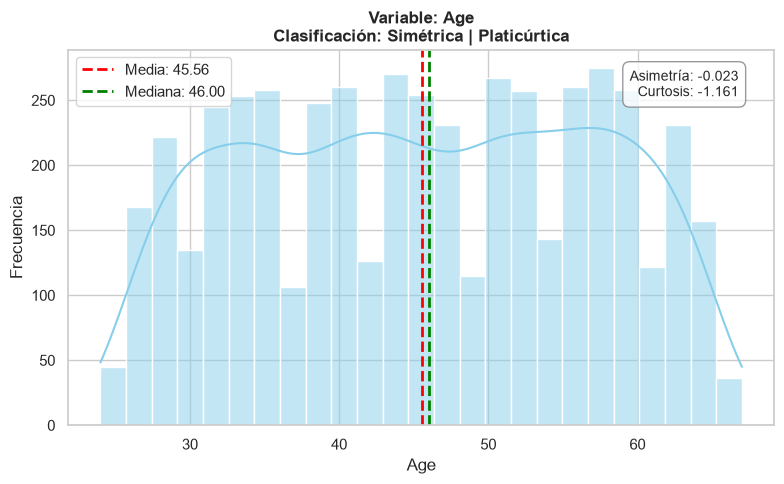

In [191]:
graficar_variable_clasificada(
    loan_df_clean,
    col="Age",
    clasif_asimetria="Simétrica",
    clasif_curtosis="Platicúrtica",
)

Age: 
* La Simetria es casi nula  (-0.023), además que la media y la mediana prácitcamente son el mismo valor, por lo cúal la curva es simétrica
* La curva tiene una forma Platicúrtica, la curtosis es de -1.16, lo cuál nos indica una distribición aplanada en el centro y con colas ligeras. Es decir las edades de distribuyen unirme a lo largo del intervalo. 

* En conclusión, la distribución si coincide con lo esperado

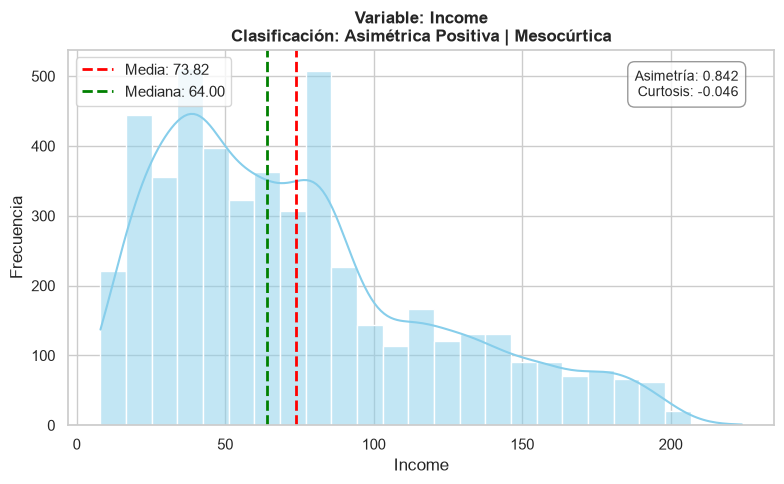

In [192]:
graficar_variable_clasificada(
    loan_df_clean,
    col="Income",
    clasif_asimetria="Asimétrica Positiva",
    clasif_curtosis="Mesocúrtica",
)

Income: 
* La distribución de la variable experiencia tiene un sesgo positvo (asimetría = 0.842), la media se despega mucho de la mediana (74 vs 64), esto quiere decir que existen outliers, es decir personas que ganan mucho mas que el resto.
* La curva tiene una forma Mesocúrtica, la curtosis es casi nula (-0.046), lo cual indica que la dispersión de los datos alrededor del centro siguen una forma similar a la normal

* En conclusión, la distribución si coincide con lo esperado

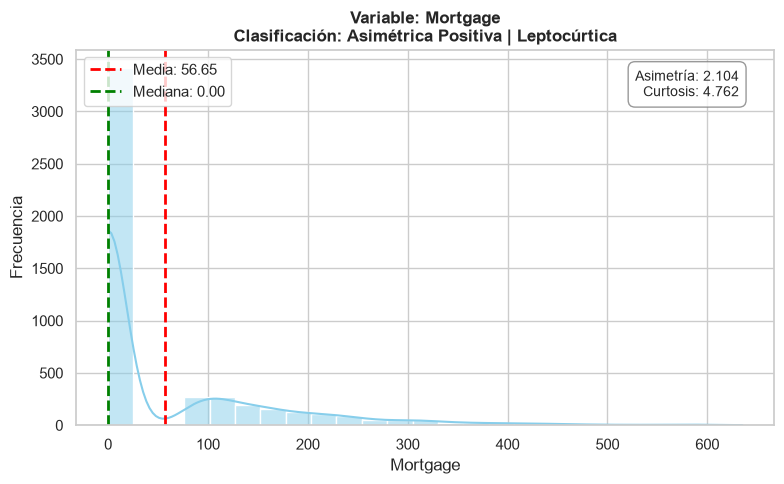

In [193]:
graficar_variable_clasificada(
    loan_df_clean,
    col="Mortgage",
    clasif_asimetria="Asimétrica Positiva",
    clasif_curtosis="Leptocúrtica",
)

Mortgage: 
* La curva tiene un fuerte sesgo positivo, con un valor alto de 2.1, la media de 56.6 supera por mucho a la mediana (0). Es interesante ya que con esto sabemos que al menos un 50% de la población no tiene una hipoteca. 

* La curva tiene una curtosis Leptocúrtica (un pico demasiado pronunciado y colas pesadas), el valor de la curtosis es de 4.7, lo que inidica una gran concentración de datos sobre el valor del 0

CONCLUSIÓN: La recomendación para comparar esta variable es filtrarla únicamente a los clientes que si tienen hipotéca. A continuación se presentan dichos resultados:


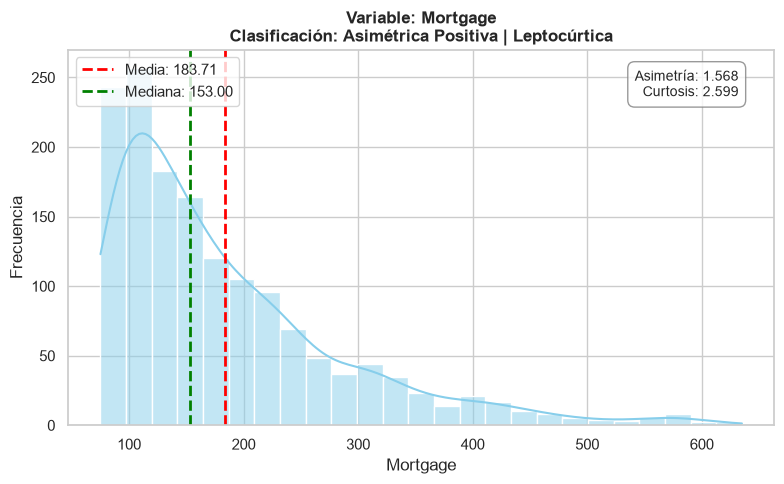

In [194]:
graficar_variable_clasificada(
    loan_df_clean.query('Mortgage>0'),
    col="Mortgage",
    clasif_asimetria="Asimétrica Positiva",
    clasif_curtosis="Leptocúrtica",
)

Mortage (solo personas con hipoteca): 

* La curva muestra muestra una Asimetría Positiva (1.57), al eliminar a la población que no tiene hipoteca, la mediana sube a 153 y la media a 183.71. Se mantiene el sesgo a la derecha porque la mayoría de los créditos contratados son de montos moderados (entre 80 y 200), mientras que un grupo reducido con créditos muy altos (hasta >600) mantiene la cola extendida.

* Curtosis Leptocúrtica (2.6), aunque disminuyó sustancialmente respecto a la variable completa (4.8), se mantiene por encima de 0.5. Esto demuestra que incluso entre los endeudados hay una alta concentración en montos bajos/medios y presencia de outliers en montos altos.

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

In [195]:
est_cat = loan_df_clean[cat_cols].astype(str).describe().T

est_cat["%_moda"] = (est_cat["freq"] / est_cat["count"] * 100).round(2)

est_cat = est_cat[["count", "unique", "top", "freq", "%_moda"]]

display(est_cat)

,count,unique,top,freq,%_moda
ZIP Code,4942,468,94720,163,3.3
Education,4942,3,1,2079,42.07
Personal Loan,4942,2,0,4463,90.31
Securities Account,4942,2,0,4427,89.58
CD Account,4942,2,0,4641,93.91
Online,4942,2,1,2952,59.73
CreditCard,4942,2,0,3489,70.6


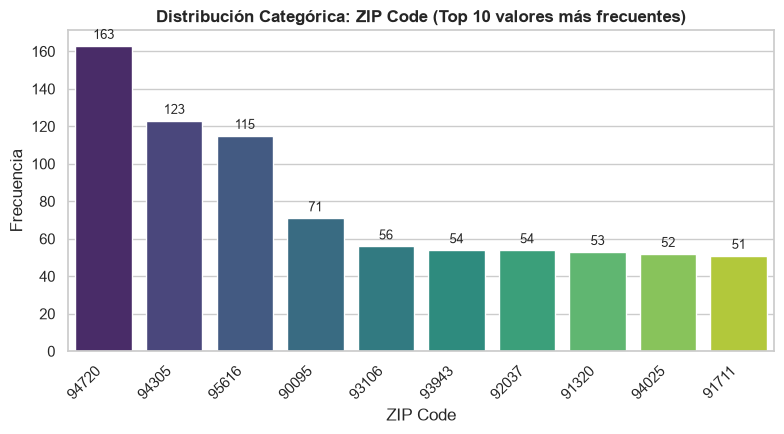

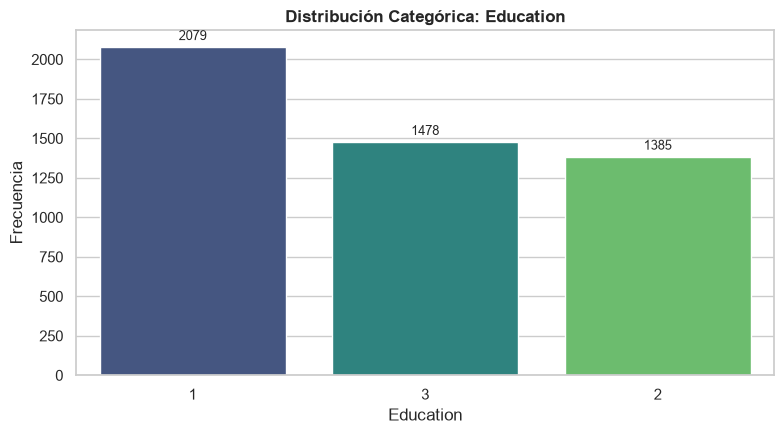

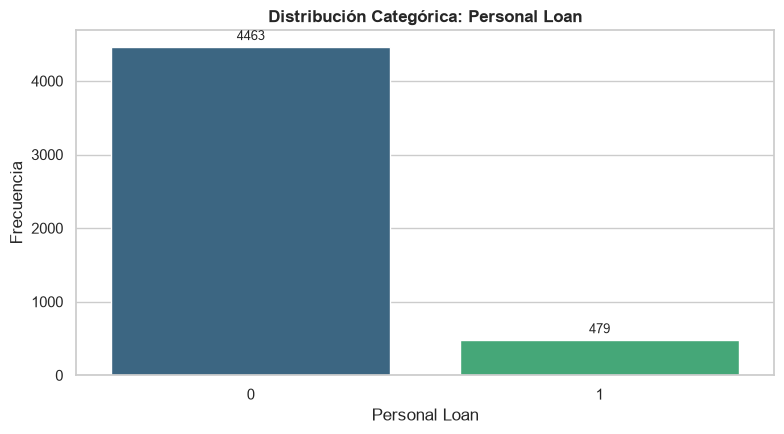

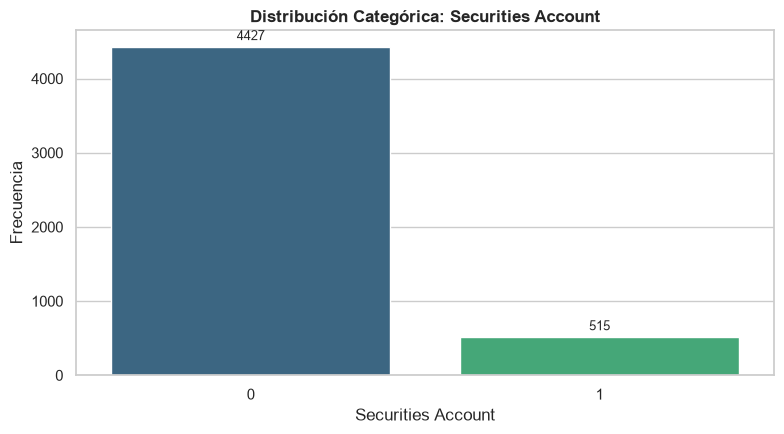

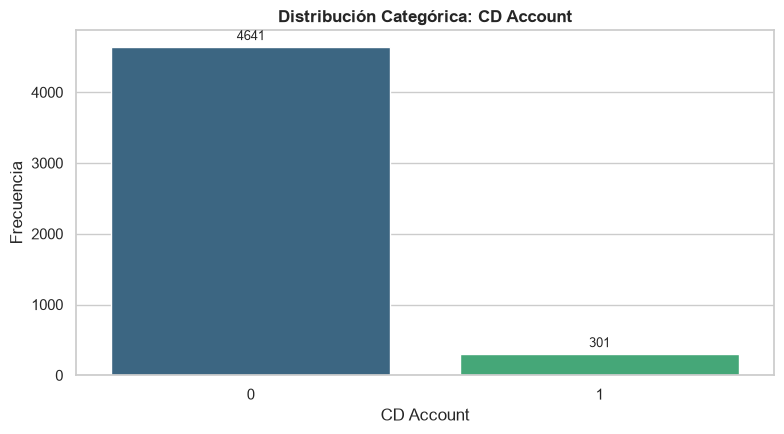

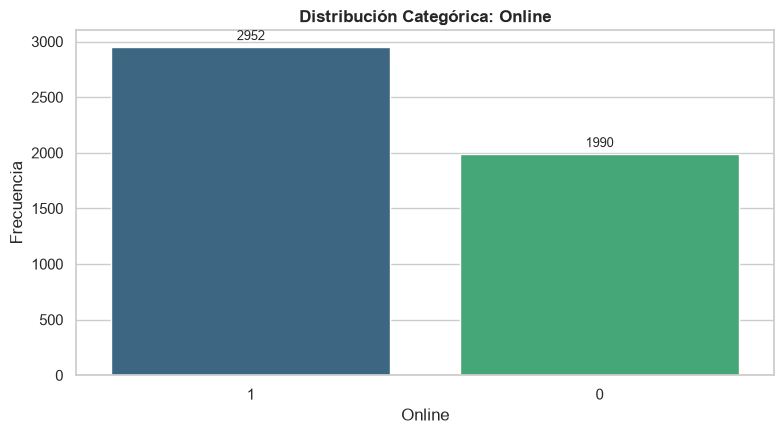

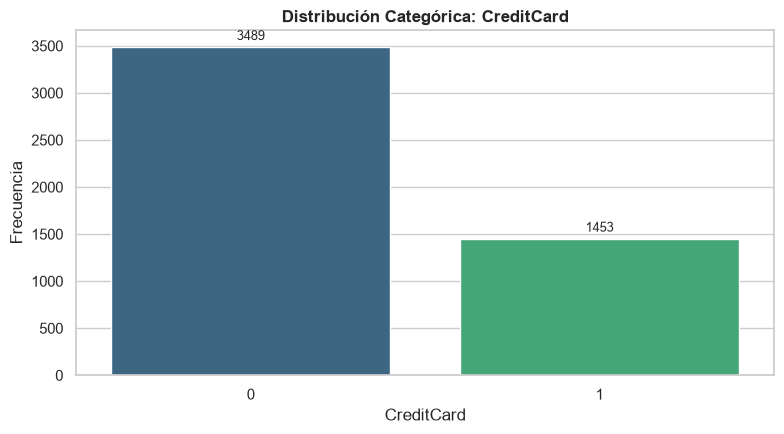

In [196]:

sns.set_theme(style="whitegrid")

for col in cat_cols:
    plt.figure(figsize=(8, 4.5))

    # 1. Conteo de frecuencias
    val_counts = loan_df_clean[col].value_counts()
    es_alta_cardinalidad = len(val_counts) > 10

    if es_alta_cardinalidad:
        data_plot = val_counts.head(10).reset_index()
        titulo_extra = " (Top 10 valores más frecuentes)"
    else:
        data_plot = val_counts.reset_index()
        titulo_extra = ""

    data_plot.columns = [col, "Frecuencia"]

    # FIX 1: Convertir a string para forzar a Seaborn a tratarlo como categoría discreta
    data_plot[col] = data_plot[col].astype(str)

    # 2. Gráfico de barras
    ax = sns.barplot(
        data=data_plot,
        x=col,
        y="Frecuencia",
        hue=col,
        palette="viridis",
        legend=False,
        order=data_plot[col],
    )

    # 3. Anotar números exactos sobre las barras
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )

    plt.title(
        f"Distribución Categórica: {col}{titulo_extra}",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    # FIX 2: Especificar alineación horizontal según la rotación
    if es_alta_cardinalidad or len(data_plot[col].iloc[0]) > 6:
        plt.xticks(rotation=45, ha="right")
    else:
        plt.xticks(rotation=0, ha="center")  # <--- Centra '0' y '1' bajo la barra

    plt.tight_layout()
    plt.show()

# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

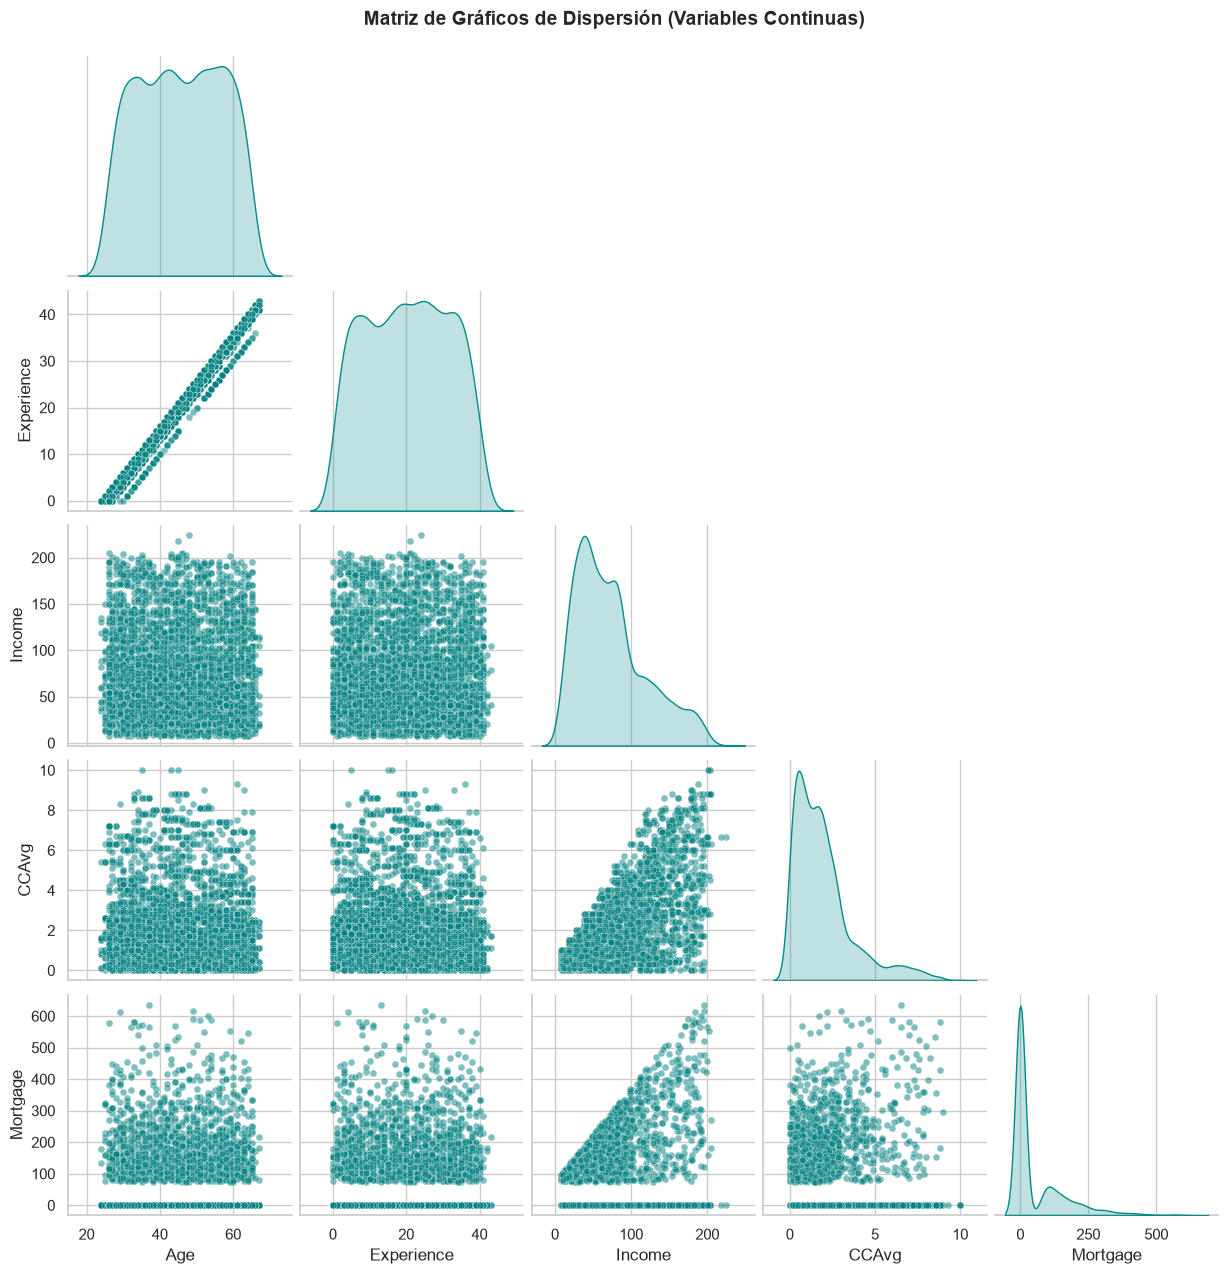

In [197]:
graficar_scatter_matrix(loan_df_clean, num_cols)

Par representativo Age vs Experience: 

Se puede apreciar como estas dos variables por su misma naturaleza están correlacionadas de manera muy fuerte y positiva. A mayor edad mayor experiencia, y esto tiene sentido, ya que es imposible que una persona de por ejemplo 20 años tenga 30 años de experiencia. 

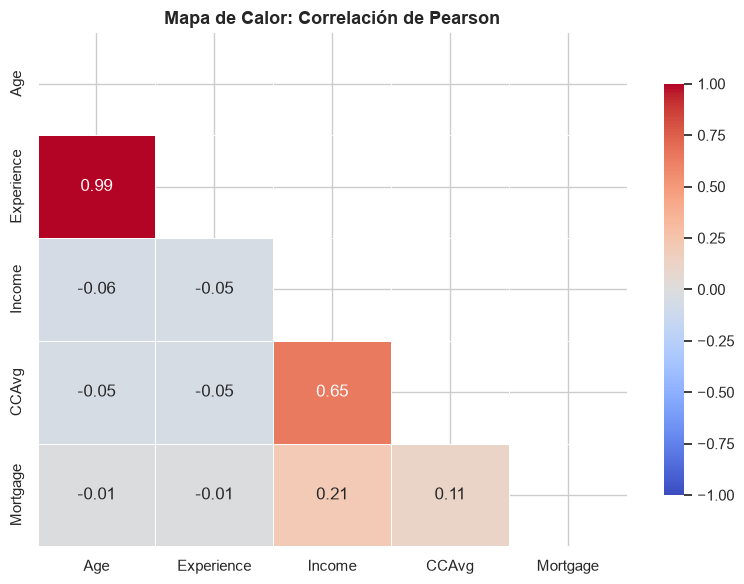

In [200]:
corr_df = graficar_matriz_correlacion(loan_df_clean, num_cols)

El valor numérico coincide totalmente con lo esperado, las variables Experience y Age están correlacionadas en un 0.99, esto es prácticamente una correlación perfecta. 

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


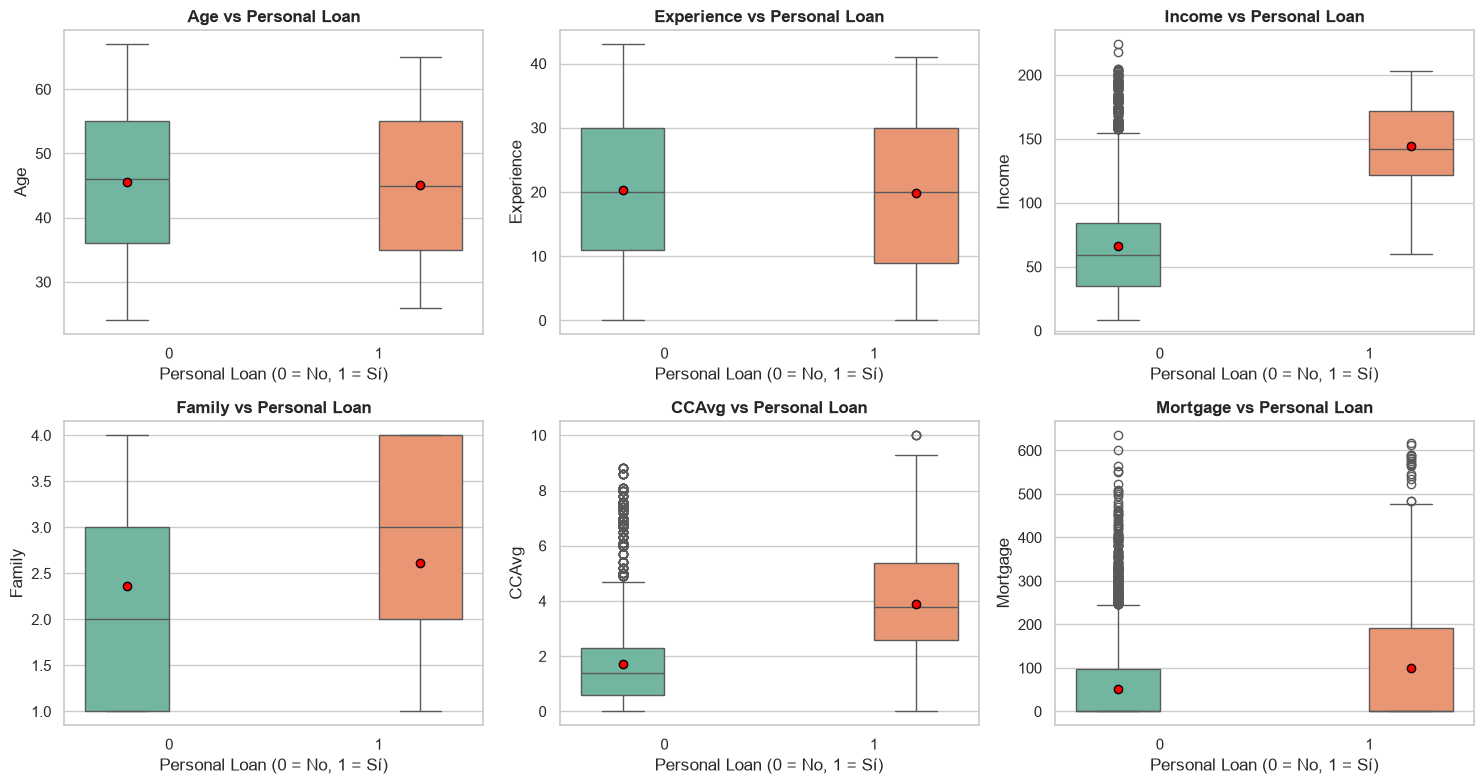

In [203]:
analizar_numericas_vs_target(loan_df_clean, num_cols)

En este análisis de las variables numéricas podemos ver que algunas variables tienen prácticamente la distribución sin importar el valor de Personal Loan y otras variables donde su distribución si cambia (variables que sí discriminan). Entre las que sí discriminan están: 

* Si Discriminan: Income, Family, CCAg, Mortage
* No Discriminan: Age, Experience

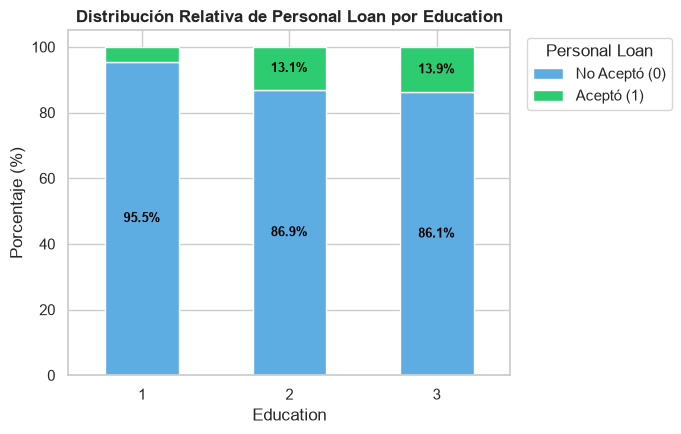

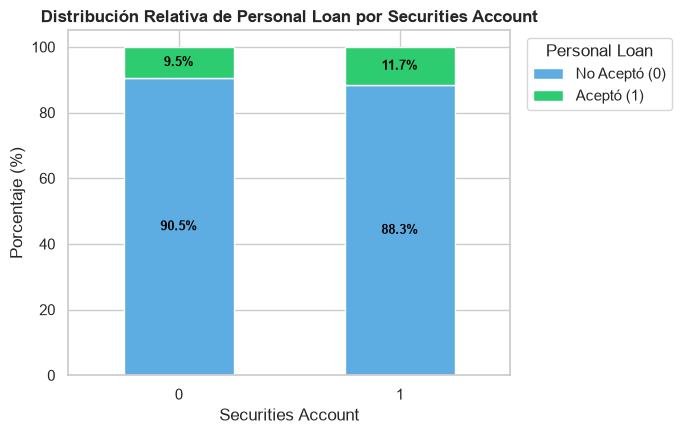

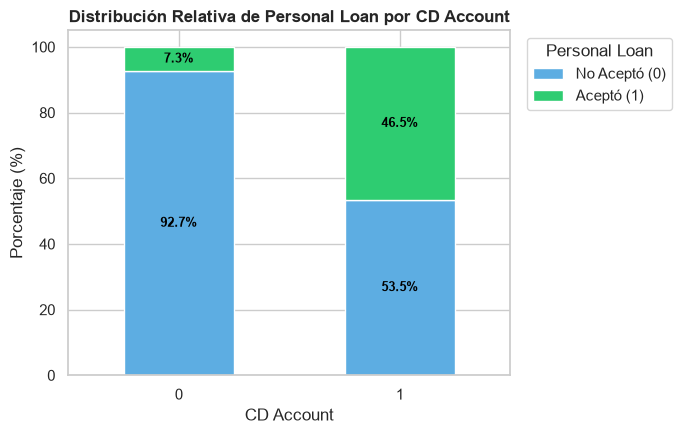

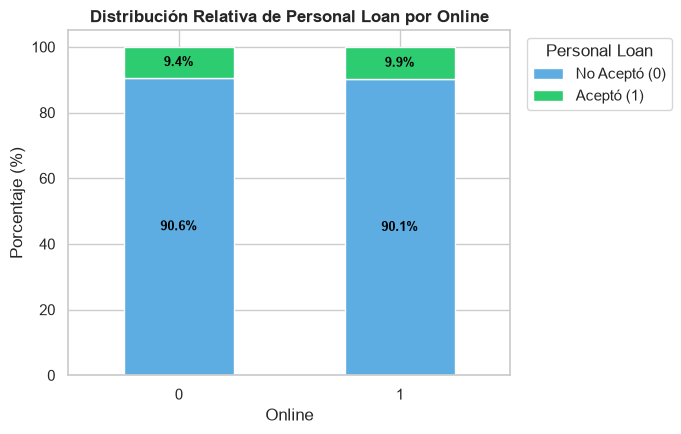

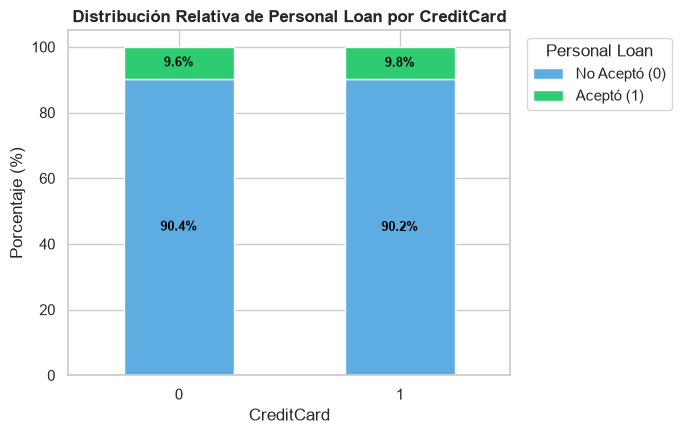

In [206]:
analizar_categoricas_vs_target(loan_df_clean, cat_cols)

Conclusiones por Variable: 

* Education: Es más dificil que acepten un crédito bancario los graduados (1), vs los universitarios y de postgrado
* Securities Account: De una manera muy ligera los clientes con cuenta de valores aceptan más el crédito bancario versu las personas que no tienen cuenta. 
* CD Account: Discrimina de manera fuerte. Las personas que sí cuentan con un depositado de depostivo aceptan mucho mas el crédito versus las personas que no cuentan con certificado (mas una realción de 6:1)
* Online: No discrimina, no influye si las personas usan los servicios en línea o no en la propensión para tomar un crédito bancario 
* Credit Card: No discrimina, no influye si las personas tienen o no tarjeta de crédito en la propensión para tomar un crédito bancario 


---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   Google. (2026). *ChatGPT (basado en Flash)* [Modelo de lenguaje grande], utilizado para generación de las funciones de código y corrección de errores. https://gemini.google.com/

---

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---